In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/Colab Notebooks/ speach_gen/asr-numbers-recognition-in-russian.zip" "/content/asr-numbers-recognition-in-russian.zip"
!unzip /content/asr-numbers-recognition-in-russian.zip -d /content/asr-numbers-recognition-in-russian

In [9]:
!pip install num2words
!pip install python-Levenshtein

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 16.5 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=ed4070510b16473be1f56c9ba537c2677f625b8f60148c13e97baec46250b432
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 108.5 MB/s eta 0:00:00


----------
---------
###**попытка 1**


In [12]:
!pip -q install torchaudio==2.4.* num2words==0.5.* soundfile==0.12.*


In [17]:
!cp "/content/drive/MyDrive/Colab Notebooks/ speach_gen/asr-numbers-recognition-in-russian.zip" "/content/asr-numbers-recognition-in-russian.zip"
!unzip /content/asr-numbers-recognition-in-russian.zip -d /content/asr-numbers-recognition-in-russian

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/asr-numbers-recognition-in-russian/train/99b18001b5.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99b31b2b81.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99be419888.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99be9b3c6a.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99bf4c4393.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99c09be5fc.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99c3935984.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99c86c8cd0.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99cc5a951a.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99cebb9560.wav  
  inflating: /content/asr-numbers-recognition-in-russian/train/99d0eb494e.wav  
  inflating: /content/asr-numbers-recognition-in-rus

In [1]:
# базовые импорты и пути
import os, sys, json, random, math, gc
from pathlib import Path

DATA_ROOT = Path("/content/asr-numbers-recognition-in-russian").resolve()
assert DATA_ROOT.exists(), f"Не найдено: {DATA_ROOT}"

TRAIN_CSV = DATA_ROOT / "train.csv"
DEV_CSV   = DATA_ROOT / "dev.csv"
TEST_CSV  = DATA_ROOT / "test.csv"

print("Файлы:", TRAIN_CSV.exists(), DEV_CSV.exists(), TEST_CSV.exists())

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


Файлы: True True True


'cuda'

In [2]:
# генерация norm_text для train/dev
import pandas as pd
from num2words import num2words
import random, re

def variants_ru(n: int):
    base = num2words(n, lang='ru')  # "двести восемьдесят тысяч пятьсот двадцать"
    v = {base}
    v.add(base.replace(" и ", " "))
    v.add(base.replace("одна тысяча", "тысяча"))
    v2 = set()
    for s in list(v):
        v2.add(s.replace("-", " "))
        v2.add(re.sub(r"-", "", s))
    v |= v2
    return sorted({re.sub(r"\s+", " ", s).strip() for s in v})

def add_norm_text(in_csv: Path, out_csv: Path, deterministic=False, n_variants=3):
    df = pd.read_csv(in_csv)
    texts = []
    for val in df["transcription"].astype(int).tolist():
        vs = variants_ru(val)
        if deterministic:
            text = vs[0]
        else:
            text = random.choice(vs[:max(1, min(n_variants, len(vs)))])
        texts.append(text)
    df["norm_text"] = texts
    df.to_csv(out_csv, index=False)
    return out_csv

TRAIN_NORM_CSV = DATA_ROOT / "train_norm.csv"
DEV_NORM_CSV   = DATA_ROOT / "dev_norm.csv"

add_norm_text(TRAIN_CSV, TRAIN_NORM_CSV, deterministic=False, n_variants=3)
add_norm_text(DEV_CSV,   DEV_NORM_CSV,   deterministic=True,  n_variants=1)

TRAIN_NORM_CSV, DEV_NORM_CSV


(PosixPath('/content/asr-numbers-recognition-in-russian/train_norm.csv'),
 PosixPath('/content/asr-numbers-recognition-in-russian/dev_norm.csv'))

In [3]:
# утилиты
import torchaudio, torch, numpy as np

# Алфавит
RUS_LETTERS = list("абвгдеёжзийклмнопрстуфхцчшщъыьэюя")
EXTRA = [" "]
VOCAB = ["<blank>"] + RUS_LETTERS + EXTRA
CHAR2ID = {c:i for i,c in enumerate(VOCAB)}
ID2CHAR = {i:c for c,i in CHAR2ID.items()}

# Аудио
def load_audio(path, target_sr=16000):
    wav, sr = torchaudio.load(str(path))
    if wav.size(0) > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, sr, target_sr)
    wav = wav / max(wav.abs().max().item(), 1e-6)
    return wav.squeeze(0)  # [T]

def trim_silence(wav, sr=16000, top_db=30):
    frame = int(0.03 * sr)
    hop = int(0.01 * sr)
    if wav.ndim == 1: wav = wav.unsqueeze(0)
    env = wav.abs().unfold(-1, frame, hop).mean(dim=-1).squeeze(0)
    thr = env.max() / (10**(top_db/20)) if env.numel() else 0.0
    idx = (env > thr).nonzero().flatten()
    if idx.numel() == 0:
        return wav.squeeze(0)
    start = max(0, idx[0]*hop - hop)
    end = min(wav.size(-1), (idx[-1]*hop + frame + hop))
    return wav.squeeze(0)[start:end]

class LogMelSpec(torch.nn.Module):
    def __init__(self, sr=16000, n_fft=400, hop=160, n_mels=80):
        super().__init__()
        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=sr, n_fft=n_fft, win_length=n_fft, hop_length=hop,
            f_min=20.0, f_max=sr/2, n_mels=n_mels, center=True, power=2.0
        )
        self.db = torchaudio.transforms.AmplitudeToDB(stype="power")
    def forward(self, wav):  # [T]
        S = self.mel(wav)
        S = self.db(S)
        S = (S - S.mean()) / (S.std() + 1e-5)
        return S  # [M, T]

# Аугментации
def speed_perturb(wav, sr=16000):
    rate = random.choice([0.9, 1.0, 1.1])
    if rate == 1.0: return wav
    new_sr = int(sr * rate)
    wav = torchaudio.functional.resample(wav, sr, new_sr)
    wav = torchaudio.functional.resample(wav, new_sr, sr)
    return wav

class SpecAugment(torch.nn.Module):
    def __init__(self, freq_mask=8, time_mask=16, n_freq_masks=2, n_time_masks=2):
        super().__init__()
        self.freq_mask, self.time_mask = freq_mask, time_mask
        self.nf, self.nt = n_freq_masks, n_time_masks
    def forward(self, spec):  # [B, M, T]
        out = spec.clone()
        B, M, T = out.shape
        for b in range(B):
            for _ in range(self.nf):
                f = random.randint(0, self.freq_mask)
                f0 = random.randint(0, max(0, M - f))
                out[b, f0:f0+f, :] = 0
            for _ in range(self.nt):
                t = random.randint(0, self.time_mask)
                t0 = random.randint(0, max(0, T - t))
                out[b, :, t0:t0+t] = 0
        return out

# Парсер слов -> число [1000..999999]
import re
UNITS = {"ноль":0,"один":1,"одна":1,"два":2,"две":2,"три":3,"четыре":4,"пять":5,"шесть":6,"семь":7,"восемь":8,"девять":9}
TEENS = {"десять":10,"одиннадцать":11,"двенадцать":12,"тринадцать":13,"четырнадцать":14,"пятнадцать":15,"шестнадцать":16,"семнадцать":17,"восемнадцать":18,"девятнадцать":19}
TENS = {"двадцать":20,"тридцать":30,"сорок":40,"пятьдесят":50,"шестьдесят":60,"семьдесят":70,"восемьдесят":80,"девяносто":90}
HUNDREDS = {"сто":100,"двести":200,"триста":300,"четыреста":400,"пятьсот":500,"шестьсот":600,"семьсот":700,"восемьсот":800,"девятьсот":900}
THOUS_FORMS = {"тысяча","тысячи","тысяч"}

def _norm_tokens(text):
    s = text.lower()
    s = re.sub(r"[^ а-яё-]", " ", s).replace("-", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s.split()

def _parse_chunk(tok):
    i, n = 0, 0
    while i < len(tok):
        w = tok[i]
        if w in HUNDREDS: n += HUNDREDS[w]; i += 1; continue
        if w in TEENS:    n += TEENS[w];    i += 1; continue
        if w in TENS:
            n += TENS[w]; i += 1
            if i < len(tok) and tok[i] in UNITS:
                n += UNITS[tok[i]]; i += 1
            continue
        if w in UNITS:    n += UNITS[w];    i += 1; continue
        if w == "и":      i += 1; continue
        break
    return n, i

def words_to_int(text):
    tok = _norm_tokens(text)
    if any(t in THOUS_FORMS for t in tok):
        idx = min(i for i,t in enumerate(tok) if t in THOUS_FORMS)
        th, _ = _parse_chunk(tok[:idx])
        rs, _ = _parse_chunk(tok[idx+1:])
        return th*1000 + rs
    else:
        val, _ = _parse_chunk(tok)
        return val

def text_to_ids(s):
    return [CHAR2ID[c] for c in s if c in CHAR2ID]


In [9]:
# dataset, sampler
import pandas as pd
from torch.utils.data import Dataset, DataLoader, Sampler
import numpy as np

class NumbersDataset(Dataset):
    def __init__(self, csv_path: Path, root_dir: Path, train=True, sr=16000, n_mels=80):
        self.df = pd.read_csv(csv_path)
        self.root = root_dir
        self.train = train
        self.sr = sr
        self.feat = LogMelSpec(sr=sr, n_mels=n_mels)
        self.max_samples_train = int(5.6 * sr)
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        wav = load_audio(self.root / r["filename"])
        if self.train:
            wav = trim_silence(wav, sr=self.sr)
            wav = speed_perturb(wav, sr=self.sr)
            if wav.numel() > self.max_samples_train:
                wav = wav[:self.max_samples_train]
        spec = self.feat(wav)               # [M, T]
        target_text = r["norm_text"]
        target = torch.tensor(text_to_ids(target_text), dtype=torch.long)
        return spec, target, r["spk_id"], r.get("gender", "na")

def collate_fn(batch):
    specs, targets, spk, gender = zip(*batch)
    M = specs[0].shape[0]
    T = [s.shape[1] for s in specs]
    maxT = max(T)
    X = torch.zeros(len(specs), M, maxT)
    for i,s in enumerate(specs):
        X[i, :, :s.shape[1]] = s
    y_list = list(targets)
    L = torch.tensor([t.numel() for t in y_list], dtype=torch.long)
    return X, y_list, torch.tensor(T, dtype=torch.long), L, list(spk), list(gender)

class LengthBucketBatchSampler(Sampler):
    def __init__(self, lengths, batch_size=24, n_buckets=4, shuffle=True):
        self.batch_size, self.shuffle = batch_size, shuffle
        qs = np.linspace(0, 1, n_buckets+1)
        edges = np.quantile(lengths, qs)
        self.buckets = [[] for _ in range(n_buckets)]
        for i, L in enumerate(lengths):
            b = min(n_buckets-1, np.searchsorted(edges, L, side='right')-1)
            self.buckets[b].append(i)
    def __iter__(self):
        if self.shuffle:
            for b in self.buckets: random.shuffle(b)
        batches = []
        for b in self.buckets:
            for i in range(0, len(b), self.batch_size):
                batches.append(b[i:i+self.batch_size])
        if self.shuffle: random.shuffle(batches)
        for bt in batches: yield bt
    def __len__(self):
        import math
        return sum(math.ceil(len(b)/self.batch_size) for b in self.buckets)

# Быстрая оценка длины по метаданным файла без декодирования
def fast_num_frames(path):
    try:
        info = torchaudio.info(str(path))
        return info.num_frames
    except:
        wav = load_audio(path)
        return wav.numel()

def collect_train_lengths(train_csv: Path, root_dir: Path):
    df = pd.read_csv(train_csv)
    arr = []
    for fn in df["filename"].tolist():
        arr.append(fast_num_frames(root_dir / fn))
    return arr

train_lengths = collect_train_lengths(TRAIN_NORM_CSV, DATA_ROOT)
len(train_lengths), int(np.mean(train_lengths)/16000), int(np.max(train_lengths)/16000)


In [8]:
# модель и метрики
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, k=5, s=2, p=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c_in, c_out, k, stride=s, padding=p, bias=False),
            nn.BatchNorm1d(c_out),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class CRDNN(nn.Module):
    def __init__(self, n_mels, vocab_size, rnn_hidden=256, rnn_layers=2):
        super().__init__()
        self.conv = nn.Sequential(
            ConvBlock(n_mels, 128, k=5, s=2, p=2),
            ConvBlock(128,   128, k=5, s=2, p=2),
            ConvBlock(128,   128, k=5, s=1, p=2),
        )
        self.proj = nn.Linear(128, rnn_hidden*2)
        self.rnn = nn.GRU(input_size=rnn_hidden*2, hidden_size=rnn_hidden,
                          num_layers=rnn_layers, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(rnn_hidden*2, vocab_size)

    def forward(self, spec):  # [B, M, T]
        x = self.conv(spec)               # [B, C, T']
        x = x.transpose(1, 2)             # [B, T', C]
        x = self.proj(x)                  # [B, T', 2H]
        x, _ = self.rnn(x)                # [B, T', 2H]
        logits = self.classifier(x)       # [B, T', V]
        return logits.transpose(0, 1)     # [T', B, V] для CTC

def ctc_greedy(logits_t_b_v, blank_id=0):
    T, B, V = logits_t_b_v.shape
    hyps = []
    for b in range(B):
        path = logits_t_b_v[:, b, :].argmax(dim=-1).cpu().numpy()
        last = blank_id
        out = []
        for p in path:
            p = int(p)
            if p != last and p != blank_id:
                out.append(p)
            last = p
        hyps.append("".join(ID2CHAR[i] for i in out))
    return hyps

def edit_distance(a, b):
    m, n = len(a), len(b)
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev, dp[0] = dp[0], i
        for j in range(1, n+1):
            prev, dp[j] = dp[j], min(dp[j]+1, dp[j-1]+1, prev + (a[i-1]!=b[j-1]))
    return dp[n]


In [6]:
# train/eval loop
from torch.utils.data import DataLoader

def evaluate_greedy(model, dl, device=DEVICE):
    model.eval()
    tot_err, tot_len = 0, 0
    with torch.no_grad():
        for X, y_list, T, L, spk, gender in dl:
            X = X.to(device)
            logits = model(X)                     # [T', B, V]
            hyp_txts = ctc_greedy(logits)
            for hyp, tgt in zip(hyp_txts, y_list):
                ref = "".join(ID2CHAR[i.item()] for i in tgt)
                e = edit_distance(hyp, ref)
                tot_err += e
                tot_len += max(1, len(ref))
    return tot_err / tot_len

def train_main(epochs=20, batch_size=24, lr=1e-3):
    ds_tr = NumbersDataset(TRAIN_NORM_CSV, DATA_ROOT, train=True)
    ds_dv = NumbersDataset(DEV_NORM_CSV,   DATA_ROOT, train=False)
    sampler = LengthBucketBatchSampler([l/16000 for l in train_lengths], batch_size=batch_size, n_buckets=4)
    dl_tr = DataLoader(ds_tr, batch_sampler=sampler, collate_fn=collate_fn, num_workers=4, pin_memory=True, persistent_workers=True)
    dl_dv = DataLoader(ds_dv, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=2)

    model = CRDNN(n_mels=80, vocab_size=len(VOCAB), rnn_hidden=256, rnn_layers=2).to(DEVICE)
    ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)
    specaug = SpecAugment()

    best = 1e9
    os.makedirs("/content/checkpoints", exist_ok=True)

    for ep in range(1, epochs+1):
        model.train()
        run_loss = 0.0
        for X, y_list, T, L, spk, gender in dl_tr:
            X = X.to(DEVICE)
            X = specaug(X)
            logits = model(X)                           # [T', B, V]
            log_probs = logits.log_softmax(dim=-1)
            input_lengths = torch.full((logits.size(1),), fill_value=logits.size(0), dtype=torch.long, device=DEVICE)
            targets = torch.cat(y_list).to(DEVICE)
            target_lengths = torch.tensor([t.numel() for t in y_list], dtype=torch.long, device=DEVICE)
            loss = ctc_loss(log_probs, targets, input_lengths, target_lengths)

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            run_loss += loss.item()

        dev_cer = evaluate_greedy(model, dl_dv, device=DEVICE)
        sched.step(dev_cer)
        avg_loss = run_loss / max(1, len(dl_tr))
        print(f"epoch {ep:02d} | train_ctc={avg_loss:.3f} | dev_CER(greedy)={dev_cer:.4f}")
        if dev_cer < best:
            best = dev_cer
            torch.save(model.state_dict(), "/content/checkpoints/best.pt")
            print("  saved /content/checkpoints/best.pt")

    return best

best_cer = train_main(epochs=20, batch_size=24, lr=1e-3)
best_cer


epoch 01 | train_ctc=0.284 | dev_CER(greedy)=0.1710
  saved /content/checkpoints/best.pt
epoch 02 | train_ctc=0.028 | dev_CER(greedy)=0.1448
  saved /content/checkpoints/best.pt
epoch 03 | train_ctc=0.021 | dev_CER(greedy)=0.1321
  saved /content/checkpoints/best.pt
epoch 04 | train_ctc=0.019 | dev_CER(greedy)=0.1727
epoch 05 | train_ctc=0.019 | dev_CER(greedy)=0.1236
  saved /content/checkpoints/best.pt
epoch 06 | train_ctc=0.016 | dev_CER(greedy)=0.1495
epoch 07 | train_ctc=0.016 | dev_CER(greedy)=0.1295
epoch 08 | train_ctc=0.016 | dev_CER(greedy)=0.1298
epoch 09 | train_ctc=0.012 | dev_CER(greedy)=0.1176
  saved /content/checkpoints/best.pt
epoch 10 | train_ctc=0.010 | dev_CER(greedy)=0.1051
  saved /content/checkpoints/best.pt
epoch 11 | train_ctc=0.010 | dev_CER(greedy)=0.1034
  saved /content/checkpoints/best.pt
epoch 12 | train_ctc=0.010 | dev_CER(greedy)=0.1161
epoch 13 | train_ctc=0.011 | dev_CER(greedy)=0.1257
epoch 14 | train_ctc=0.010 | dev_CER(greedy)=0.1071
epoch 15 | tr

0.09862365713960049

In [7]:
# инференс и сабмит
import pandas as pd

def transcribe_file(path, model, feat, device=DEVICE):
    wav = load_audio(path)
    spec = feat(wav).unsqueeze(0).to(device)          # [1, M, T]
    with torch.no_grad():
        logits = model(spec)                           # [T', 1, V]
    hyp_txt = ctc_greedy(logits)[0]
    val = words_to_int(hyp_txt)
    # гарантируем диапазон [1000..999999]
    val = int(max(1000, min(999999, val)))
    return val

def run_infer_and_save(test_csv: Path, root: Path, ckpt: str, out_csv: Path):
    df = pd.read_csv(test_csv)
    model = CRDNN(80, len(VOCAB), 256, 2).to(DEVICE)
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    feat = LogMelSpec()
    out = []
    for _, r in df.iterrows():
        fn = root / r["filename"]
        y = transcribe_file(fn, model, feat, device=DEVICE)
        out.append({"filename": r["filename"], "transcription": y})
    pd.DataFrame(out).to_csv(out_csv, index=False)
    return out_csv

SUB_PATH = DATA_ROOT / "submission.csv"
run_infer_and_save(TEST_CSV, DATA_ROOT, "/content/checkpoints/best.pt", SUB_PATH)
SUB_PATH, pd.read_csv(SUB_PATH).head()


/tmp/ipython-input-3287748371.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt, map_location=DEVICE))


(PosixPath('/content/asr-numbers-recognition-in-russian/submission.csv'),
               filename  transcription
 0  test/d2440788a9.mp3         460694
 1  test/e247dbf761.mp3         207723
 2  test/071f4a5be7.mp3          79187
 3  test/798bd15db7.mp3          64048
 4  test/58c0464ad5.mp3         860160)

In [10]:
# Dev-инференс и сбор предсказаний
import pandas as pd
from torch.utils.data import DataLoader

def infer_dev_predictions(ckpt_path="/content/checkpoints/best.pt", batch_size=24):
    ds_dv = NumbersDataset(DEV_NORM_CSV, DATA_ROOT, train=False)
    dl_dv = DataLoader(ds_dv, batch_size=batch_size, shuffle=False, collate_fn=collate_fn, num_workers=2)

    model = CRDNN(n_mels=80, vocab_size=len(VOCAB), rnn_hidden=256, rnn_layers=2).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    rows = []
    with torch.no_grad():
        for X, y_list, T, L, spk, gender in dl_dv:
            X = X.to(DEVICE)
            logits = model(X)                   # [T', B, V]
            hyps = ctc_greedy(logits)          # список строк
            for hyp, tgt, s, g in zip(hyps, y_list, spk, gender):
                ref_text = "".join(ID2CHAR[i.item()] for i in tgt)
                rows.append({"spk_id": s, "gender": g, "hyp_text": hyp, "ref_text": ref_text})
    return pd.DataFrame(rows)

dev_preds = infer_dev_predictions()
dev_preds.head()


/tmp/ipython-input-1997749504.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))


,spk_id,gender,hyp_text,ref_text
0,spk_J,male,восемьсот сорокд тысяч девятьсот пять,восемьсот сорок девять тысяч девятьсот пять
1,spk_I,female,деветвсятч сорок есть тысяч рад семь тысяч ч ш...,девятьсот шестьдесят семь тысяч шестьсот пятьд...
2,spk_K,female,вдоденост два двадцать дсемть тысяч дпятьдесят...,четыреста двадцать семь тысяч пятьсот двадцать...
3,spk_H,male,девяносто три тысячи семьсот пятьдесят два,девяносто три тысячи семьсот пятьдесят два
4,spk_I,female,соророк три тысячи триста пятьдесят пять,сорок три тысячи триста пятьдесят пять


In [11]:
# Метрики: CER, accuracy числа; разбиение на inD/ooD; гармоническое среднее.
import numpy as np

def edit_distance(a, b):
    m, n = len(a), len(b)
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev, dp[0] = dp[0], i
        for j in range(1, n+1):
            prev, dp[j] = dp[j], min(dp[j]+1, dp[j-1]+1, prev + (a[i-1]!=b[j-1]))
    return dp[n]

# загрузим исходные dev и train, чтобы определить inD/ooD по спикерам
df_train = pd.read_csv(TRAIN_NORM_CSV)
df_dev   = pd.read_csv(DEV_NORM_CSV)

train_spk = set(df_train["spk_id"].unique())
dev_spk   = set(df_dev["spk_id"].unique())
ind_spk   = sorted(dev_spk & train_spk)   # in-domain
ood_spk   = sorted(dev_spk - train_spk)   # out-of-domain

# Добавим числовые цели из dev.csv (целевое число)
df_dev_raw = pd.read_csv(DEV_CSV)[["filename","transcription","spk_id"]]

# Соединим dev_preds с исходными целями по порядку (они соответствуют батчу из NumbersDataset)
preds = dev_preds.copy()
# Для надёжности добавим индекс и сольём с df_dev по спикеру и позиции:
preds["row_id"] = np.arange(len(preds))
tmp = df_dev[["spk_id","norm_text"]].copy()
tmp["row_id"] = np.arange(len(tmp))
tmpnum = df_dev_raw[["spk_id","transcription"]].copy()
tmpnum["row_id"] = np.arange(len(tmpnum))

preds = preds.merge(tmp[["row_id"]], on="row_id", how="left")
preds = preds.merge(tmpnum[["row_id","transcription"]], on="row_id", how="left")

# CER и точность числа
tot_err, tot_len, correct_nums = 0, 0, 0
group_err = {"inD": [0,0], "ooD": [0,0]}  # [err, len]
for i, r in preds.iterrows():
    hyp, ref = r["hyp_text"], r["ref_text"]
    e = edit_distance(hyp, ref)
    L = max(1, len(ref))
    tot_err += e; tot_len += L
    val_pred = words_to_int(hyp)
    val_true = int(r["transcription"])
    correct_nums += int(val_pred == val_true)
    # inD/ooD
    key = "inD" if r["spk_id"] in ind_spk else "ooD"
    group_err[key][0] += e
    group_err[key][1] += L

cer_all = tot_err / tot_len
acc_num = correct_nums / len(preds)

cer_inD = group_err["inD"][0] / max(1, group_err["inD"][1])
cer_ooD = group_err["ooD"][0] / max(1, group_err["ooD"][1])

def harmonic_mean(a, b):  # ожидание Kaggle-подобной метрики на dev
    return 2.0 / (1.0/max(1e-9,a) + 1.0/max(1e-9,b))

score_hmean = harmonic_mean(cer_inD, cer_ooD)

print(f"CER(dev, все):        {cer_all*100:.2f}%")
print(f"CER(dev, inD):        {cer_inD*100:.2f}%")
print(f"CER(dev, ooD):        {cer_ooD*100:.2f}%")
print(f"H-mean(inD,ooD CER):  {score_hmean*100:.2f}%  (меньше — лучше)")
print(f"Accuracy числа(dev):  {acc_num*100:.2f}%  (больше — лучше)")
print(f"inD speakers: {len(ind_spk)} | ooD speakers: {len(ood_spk)}")


CER(dev, все):        9.86%
CER(dev, inD):        8.68%
CER(dev, ooD):        10.29%
H-mean(inD,ooD CER):  9.42%  (меньше — лучше)
Accuracy числа(dev):  53.86%  (больше — лучше)
inD speakers: 6 | ooD speakers: 4


In [12]:
# Топ-10 спикеров с наибольшим CER
from collections import defaultdict

agg = defaultdict(lambda: [0,0])  # err, len
for _, r in preds.iterrows():
    e = edit_distance(r["hyp_text"], r["ref_text"])
    L = max(1, len(r["ref_text"]))
    agg[r["spk_id"]][0] += e; agg[r["spk_id"]][1] += L

spk_table = sorted(((k, v[0]/max(1,v[1])) for k,v in agg.items()), key=lambda x: -x[1])
for k, cer in spk_table[:10]:
    print(f"{k}: CER={cer*100:.2f}%")


spk_I: CER=18.24%
spk_K: CER=14.01%
spk_F: CER=11.00%
spk_A: CER=10.71%
spk_C: CER=10.48%
spk_D: CER=7.64%
spk_E: CER=7.11%
spk_J: CER=6.80%
spk_B: CER=5.19%
spk_H: CER=4.82%


----

----
----
###**попытка 2**

In [13]:
# Fuzzy-правка слов + безопасная денормализация в число [1000..999999]
import re

VALID_WORDS = set(list(UNITS) + list(TEENS) + list(TENS) + list(HUNDREDS) + list(THOUS_FORMS) + ["и"])
ALIASES = {
    "шестсот": "шестьсот",
    "девяноста": "девяносто",
}

def _lev(a, b):
    m, n = len(a), len(b)
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev, dp[0] = dp[0], i
        for j in range(1, n+1):
            prev, dp[j] = dp[j], min(dp[j]+1, dp[j-1]+1, prev + (a[i-1]!=b[j-1]))
    return dp[n]

def _normalize_and_split(text):
    s = text.lower()
    s = re.sub(r"[^ а-яё-]", " ", s).replace("-", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s.split()

def fuzzy_fix_tokens(tokens, max_dist=2):
    fixed = []
    for w in tokens:
        if w in VALID_WORDS:
            fixed.append(w); continue
        if w in ALIASES:
            fixed.append(ALIASES[w]); continue
        if len(w) >= 3:
            best, dmin = None, 10**9
            for v in VALID_WORDS:
                d = _lev(w, v)
                if d < dmin:
                    dmin, best = d, v
                    if dmin == 0: break
            if dmin <= max_dist:
                fixed.append(best); continue
        if w == "и":
            fixed.append(w)
    return fixed

def words_to_int_fuzzy(text):
    tok = fuzzy_fix_tokens(_normalize_and_split(text))
    if any(t in THOUS_FORMS for t in tok):
        idx = min(i for i,t in enumerate(tok) if t in THOUS_FORMS)
        th, _ = _parse_chunk(tok[:idx])
        rs, _ = _parse_chunk(tok[idx+1:])
        return th*1000 + rs
    else:
        val, _ = _parse_chunk(tok)
        return val

def words_to_int_safe(text):
    try:
        v = words_to_int_fuzzy(text)
        return int(max(1000, min(999999, v)))
    except:
        return 1000


In [14]:
import pandas as pd, numpy as np
from torch.utils.data import DataLoader

def cer_digits(a, b):
    a, b = str(a), str(b)
    m, n = len(a), len(b)
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev, dp[0] = dp[0], i
        for j in range(1, n+1):
            prev, dp[j] = dp[j], min(dp[j]+1, dp[j-1]+1, prev + (a[i-1]!=b[j-1]))
    return dp[n] / max(1, n)

# собираем гипотезы на dev (текст)
def infer_dev_texts(ckpt="/content/checkpoints/best.pt"):
    ds = NumbersDataset(DEV_NORM_CSV, DATA_ROOT, train=False)
    dl = DataLoader(ds, batch_size=24, shuffle=False, collate_fn=collate_fn, num_workers=2)
    model = CRDNN(80, len(VOCAB), 256, 2).to(DEVICE)
    try:
        state = torch.load(ckpt, map_location=DEVICE, weights_only=True)
    except TypeError:
        state = torch.load(ckpt, map_location=DEVICE)
    model.load_state_dict(state); model.eval()
    rows=[]
    with torch.no_grad():
        for X, y_list, T, L, spk, gender in dl:
            X = X.to(DEVICE)
            logits = model(X)
            hyps = ctc_greedy(logits)
            for hyp, s in zip(hyps, spk):
                rows.append({"spk_id": s, "hyp_text": hyp})
    return pd.DataFrame(rows)

dev_hyps = infer_dev_texts()
dev_raw = pd.read_csv(DEV_CSV)[["transcription","spk_id"]]

pred_nums = dev_hyps["hyp_text"].map(words_to_int_safe).astype(int).to_numpy()
true_nums = dev_raw["transcription"].astype(int).to_numpy()

cers = [cer_digits(p, t) for p, t in zip(pred_nums, true_nums)]
cer_all = float(np.mean(cers))

train_spk = set(pd.read_csv(TRAIN_NORM_CSV)["spk_id"].unique())
mask_ind  = dev_hyps["spk_id"].isin(train_spk).to_numpy()
cer_inD   = float(np.mean(np.array(cers)[mask_ind]))
cer_ooD   = float(np.mean(np.array(cers)[~mask_ind]))
hmean     = 2.0 / (1.0/max(1e-9,cer_inD) + 1.0/max(1e-9,cer_ooD))
acc_num   = float(np.mean(pred_nums == true_nums))

print(f"CER по цифрам (greedy+fuzzy, dev): {cer_all*100:.2f}%")
print(f"inD {cer_inD*100:.2f}% | ooD {cer_ooD*100:.2f}% | H-mean {hmean*100:.2f}%")
print(f"Accuracy по числам:                 {acc_num*100:.2f}%")


CER по цифрам (greedy+fuzzy, dev): 17.77%
inD 17.90% | ooD 17.72% | H-mean 17.81%
Accuracy по числам:                 61.72%


In [15]:
!apt -q update && apt -q install -y kenlm
!pip -q install pyctcdecode==0.5.0


Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,327 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,802 kB

In [18]:
!apt -q update
!apt -q install -y build-essential cmake libboost-all-dev zlib1g-dev libbz2-dev liblzma-dev

!git clone --depth 1 https://github.com/kpu/kenlm.git /content/kenlm
!mkdir -p /content/kenlm/build
%cd /content/kenlm/build
!cmake .. -DCMAKE_BUILD_TYPE=Release
!make -j$(nproc)
%cd /content

LMPLZ = "/content/kenlm/build/bin/lmplz"
BUILDBIN = "/content/kenlm/build/bin/build_binary"
!ls -l {LMPLZ} {BUILDBIN}


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Building dependency tree...
Reading state information...
43 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https

In [19]:
from num2words import num2words
import re

CORPUS_PATH = "/content/ru_nums_corpus.txt"
with open(CORPUS_PATH, "w", encoding="utf-8") as f:
    for n in range(1000, 1_000_000):
        s = num2words(n, lang='ru')
        s = s.replace("-", " ")
        s = re.sub(r"\s+", " ", s).strip()
        f.write(s + "\n")
print("corpus:", CORPUS_PATH)


corpus: /content/ru_nums_corpus.txt
/bin/bash: line 1: lmplz: command not found
/bin/bash: line 1: build_binary: command not found


In [20]:
!{LMPLZ} -o 3 < /content/ru_nums_corpus.txt > /content/ru_nums.arpa
!{BUILDBIN} /content/ru_nums.arpa /content/ru_nums.klm
!ls -lh /content/ru_nums.arpa /content/ru_nums.klm

=== 1/5 Counting and sorting n-grams ===
Reading /content/ru_nums_corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 6216390 types 44
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:528 2:49912492032 3:93585924096
/content/kenlm/lm/builder/adjust_counts.cc:49 in void lm::builder::{anonymous}::StatCollector::CalculateDiscounts(const lm::builder::DiscountConfig&) threw BadDiscountException because `s.n[j] == 0'.
Could not calculate Kneser-Ney discounts for 1-grams with adjusted count 3 because we didn't observe any 1-grams with adjusted count 2; Is this small or artificial data?
Try deduplicating the input.  To override this error for e.g. a class-based model, rerun with --discount_fallback

/bin/bash: line 1: 30203 Aborted                 (core dumped) /content/kenlm/build/bin/lmplz -o 3 < /con

In [21]:
!pip -q install pyctcdecode==0.5.0

In [32]:

!pip -q install pybind11==2.13.*
!pip -q install https://github.com/kpu/kenlm/archive/refs/heads/master.zip#egg=kenlm

# Проверяем, что импортируется
import kenlm
kenlm.__file__


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


'/usr/local/lib/python3.12/dist-packages/kenlm.cpython-312-x86_64-linux-gnu.so'

In [35]:
from pathlib import Path
list(Path("/content").glob("ru_nums*"))


[PosixPath('/content/ru_nums_corpus.txt'), PosixPath('/content/ru_nums.arpa')]

In [73]:
# Берём ВСЕ уникальные слова из ru_nums_corpus.txt
CORPUS_PATH = "/content/ru_nums_corpus.txt"

with open(CORPUS_PATH, "r", encoding="utf-8") as f:
    UNIGRAMS = sorted({w for line in f for w in line.strip().split()})

print("unigrams size:", len(UNIGRAMS))
print(UNIGRAMS[:30])  # проверка


unigrams size: 41
['восемнадцать', 'восемь', 'восемьдесят', 'восемьсот', 'два', 'двадцать', 'две', 'двенадцать', 'двести', 'девяносто', 'девятнадцать', 'девять', 'девятьсот', 'десять', 'один', 'одиннадцать', 'одна', 'пятнадцать', 'пять', 'пятьдесят', 'пятьсот', 'семнадцать', 'семь', 'семьдесят', 'семьсот', 'сорок', 'сто', 'три', 'тридцать', 'тринадцать']


In [51]:
import subprocess, sys

def build_arpa(corpus_path, arpa_path, order=3, mem="1G", tmpdir="/content/kenlm_tmp"):
    cmd = [LMPLZ, "-o", str(order), "--discount_fallback", "-S", mem, "-T", tmpdir]
    print("RUN:", " ".join(cmd))
    with open(corpus_path, "rb") as fin, open(arpa_path, "wb") as fout:
        proc = subprocess.run(cmd, stdin=fin, stdout=fout, stderr=subprocess.PIPE)
    ok = (proc.returncode == 0) and os.path.getsize(arpa_path) > 0
    return ok, proc.stderr.decode(errors="ignore")

ok, err = build_arpa(CORPUS_PATH, ARPA, order=3, mem="1G", tmpdir=TMPD)
print("arpa ok:", ok, "| size:", os.path.getsize(ARPA) if os.path.exists(ARPA) else 0)
print(err[:1500])  # покажем начало stderr


RUN: /content/kenlm/build/bin/lmplz -o 3 --discount_fallback -S 1G -T /content/kenlm_tmp
arpa ok: True | size: 250395
=== 1/5 Counting and sorting n-grams ===
Reading /content/ru_nums_corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 6216390 types 44
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:528 2:373475232 3:700266112
Substituting fallback discounts for order 0: D1=0.5 D2=1 D3+=1.5
Substituting fallback discounts for order 1: D1=0.5 D2=1 D3+=1.5
Substituting fallback discounts for order 2: D1=0.5 D2=1 D3+=1.5
Statistics:
1 44 D1=0.5 D2=1 D3+=1.5
2 568 D1=0.5 D2=1 D3+=1.5
3 4158 D1=0.5 D2=1 D3+=1.5
Memory estimate for binary LM:
type    kB
probing 87 assuming -p 1.5
probing 91 assuming -r models -p 1.5
trie    25 without quantization
trie    13 assuming -q 8 -b 8 quantization 
trie    2

In [52]:
import itertools, math, random

if not os.path.exists(ARPA) or os.path.getsize(ARPA) == 0:
    # Subsample до ~200k строк
    SMALL = "/content/ru_nums_corpus_200k.txt"
    if not os.path.exists(SMALL):
        step = max(1, 999000 // 200000)  # ~ каждая 5-я строка
        with open(CORPUS_PATH, "r", encoding="utf-8") as fi, open(SMALL, "w", encoding="utf-8") as fo:
            for i, line in enumerate(fi):
                if i % step == 0:
                    fo.write(line)
    print("small corpus size:", os.path.getsize(SMALL))

    ok, err = build_arpa(SMALL, ARPA, order=3, mem="1G", tmpdir=TMPD)
    print("arpa (3-gram, 200k) ok:", ok, "| size:", os.path.getsize(ARPA) if os.path.exists(ARPA) else 0)
    if not ok:
        print("stderr:", err[:1500])

    # если всё ещё не ок — пробуем 2-грамм на полном корпусе
    if (not ok) or os.path.getsize(ARPA) == 0:
        ok2, err2 = build_arpa(CORPUS_PATH, ARPA, order=2, mem="1G", tmpdir=TMPD)
        print("arpa (2-gram, full) ok:", ok2, "| size:", os.path.getsize(ARPA) if os.path.exists(ARPA) else 0)
        if not ok2:
            print("stderr(2-gram):", err2[:1500])


In [53]:
if os.path.exists(ARPA) and os.path.getsize(ARPA) > 0:
    try:
        subprocess.run([BUILDBIN, ARPA, KLM], check=True)
        print("KLM ready, size:", os.path.getsize(KLM))
        LM_PATH = KLM
    except subprocess.CalledProcessError as e:
        print("build_binary failed, остаёмся на .arpa")
        LM_PATH = ARPA
else:
    raise RuntimeError("ARPA не собрался — пришлите stderr из шага 2/3")


KLM ready, size: 90432


In [ ]:
# пути к бинарникам (если собирали KenLM как раньше)
LMPLZ = "/content/kenlm/build/bin/lmplz"
BUILDBIN = "/content/kenlm/build/bin/build_binary"

import os, subprocess, textwrap
assert os.path.exists(LMPLZ), f"Не найден {LMPLZ} — вернитесь к шагу сборки KenLM"
assert os.path.exists(BUILDBIN), f"Не найден {BUILDBIN} — вернитесь к шагу сборки KenLM"

!ls -l /content/kenlm/build/bin/lmplz /content/kenlm/build/bin/build_binary


In [56]:
# строим ARPA
!bash -lc '$LMPLZ -o 3 < /content/ru_nums_corpus.txt > /content/ru_nums.arpa'
# опционально строим бинарь (быстрее при инференсе)
!bash -lc '$BUILDBIN /content/ru_nums.arpa /content/ru_nums.klm'
!ls -lh /content/ru_nums.arpa /content/ru_nums.klm



bash: line 1: -o: command not found
bash: line 1: /content/ru_nums.arpa: Permission denied
-rw-r--r-- 1 root root   0 Sep 20 06:44 /content/ru_nums.arpa
-rw-r--r-- 1 root root 89K Sep 20 06:42 /content/ru_nums.klm


In [57]:
# ВАЖНО: никаких одинарных кавычек — используем полный путь к бинарнику.
!/content/kenlm/build/bin/lmplz -o 3 < /content/ru_nums_corpus.txt > /content/ru_nums.arpa

# Проверим, что файл непустой
!ls -lh /content/ru_nums.arpa
!head -n 5 /content/ru_nums.arpa


=== 1/5 Counting and sorting n-grams ===
Reading /content/ru_nums_corpus.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 6216390 types 44
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:528 2:49912492032 3:93585924096
/content/kenlm/lm/builder/adjust_counts.cc:49 in void lm::builder::{anonymous}::StatCollector::CalculateDiscounts(const lm::builder::DiscountConfig&) threw BadDiscountException because `s.n[j] == 0'.
Could not calculate Kneser-Ney discounts for 1-grams with adjusted count 3 because we didn't observe any 1-grams with adjusted count 2; Is this small or artificial data?
Try deduplicating the input.  To override this error for e.g. a class-based model, rerun with --discount_fallback

/bin/bash: line 1: 38480 Aborted                 (core dumped) /content/kenlm/build/bin/lmplz -o 3 < /con

In [58]:
!/content/kenlm/build/bin/build_binary /content/ru_nums.arpa /content/ru_nums.klm
!ls -lh /content/ru_nums.klm


Reading /content/ru_nums.arpa
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
End of file Byte: 0
ERROR
-rw-r--r-- 1 root root 89K Sep 20 06:42 /content/ru_nums.klm


In [83]:
# --- 0) НОРМАЛИЗУЕМ МЕТКИ ДЛЯ ДЕКОДЕРА ---
def _norm_label(tok: str) -> str:
    # blank → пустая строка
    if tok == "<blank>":
        return ""
    # одиночная буква в одинарных кавычках "'а'" → "а"
    if len(tok) == 3 and tok[0] == "'" and tok[2] == "'":
        return tok[1]
    # явный маркер пробела (на всякий) → пробел
    if tok in ("<space>", "▁"):
        return " "
    return tok

LABELS = [_norm_label(ID2CHAR[i]) for i in range(len(VOCAB))]  # длина = V (включая blank)
WORD_DELIM = " "  # у вас пробел есть в словаре (id=34)

print("V =", len(LABELS), "| first 8:", [repr(c) for c in LABELS[:8]])
print("blank label repr:", repr(LABELS[0]))
print("space label present:", " " in LABELS)


V = 35 | first 8: ["''", "'а'", "'б'", "'в'", "'г'", "'д'", "'е'", "'ё'"]
blank label repr: ''
space label present: True


In [84]:
# контроль: что greedy всё ещё ~10%
from torch.utils.data import DataLoader
import torch, numpy as np

def cer_text(pred, ref):
    m,n=len(pred),len(ref); dp=list(range(n+1))
    for i in range(1,m+1):
        prev,dp[0]=dp[0],i
        for j in range(1,n+1):
            prev,dp[j]=dp[j],min(dp[j]+1, dp[j-1]+1, prev+(pred[i-1]!=ref[j-1]))
    return dp[n]/max(1,len(ref))

def eval_greedy_text(ckpt="/content/checkpoints/best.pt"):
    ds = NumbersDataset(DEV_NORM_CSV, DATA_ROOT, train=False)
    dl = DataLoader(ds, batch_size=24, shuffle=False, collate_fn=collate_fn, num_workers=2)
    model = CRDNN(80, len(VOCAB), 256, 2).to(DEVICE)
    try:
        state = torch.load(ckpt, map_location=DEVICE, weights_only=True)
    except TypeError:
        state = torch.load(ckpt, map_location=DEVICE)
    model.load_state_dict(state); model.eval()

    # ВАЖНО: референс собираем теми же нормализованными LABELS
    tot_err=tot_len=0
    with torch.no_grad():
        for X, y_list, *_ in dl:
            X=X.to(DEVICE); lp=model(X)
            hyps = ctc_greedy(lp)
            for hyp, tgt in zip(hyps, y_list):
                ref = "".join(LABELS[i.item()] for i in tgt)
                tot_err += cer_text(hyp, ref) * len(ref)
                tot_len += len(ref)
    return tot_err/tot_len

print("Greedy CER(text) =", f"{eval_greedy_text()*100:.2f}%")


Greedy CER(text) = 9.86%


In [89]:
from pyctcdecode import build_ctcdecoder
import torch, numpy as np
from torch.utils.data import DataLoader
import os, kenlm, pyctcdecode, importlib
import pyctcdecode.language_model as pclm, pyctcdecode.decoder as pdec
pclm.kenlm = kenlm; pdec.kenlm = kenlm

# полный список слов из корпуса — это ок, что ~41–43
with open("/content/ru_nums_corpus.txt", "r", encoding="utf-8") as f:
    UNIGRAMS = sorted({w for line in f for w in line.strip().split()})
print("len(UNIGRAMS)=", len(UNIGRAMS))

LM_PATH = "/content/ru_nums.klm" if os.path.exists("/content/ru_nums.klm") else "/content/ru_nums.arpa"

def make_decoder_lm_A(alpha=0.7, beta=0.5):
    return build_ctcdecoder(LABELS, kenlm_model_path=LM_PATH, unigrams=UNIGRAMS,
                            alpha=alpha, beta=beta)

def decode_A(decoder, logits_t_b_v, beam_width=100):
    T,B,V = logits_t_b_v.shape
    outs=[]
    for b in range(B):
        lp = logits_t_b_v[:, b, :].log_softmax(dim=-1)  # ПОЛНЫЕ log_probs, без среза [:,1:]
        assert lp.shape[1] == len(LABELS)
        outs.append(decoder.decode(lp.detach().cpu().numpy().astype(np.float32),
                                   beam_width=beam_width))
    return outs

def cer_text(a,b):
    m,n=len(a),len(b); dp=list(range(n+1))
    for i in range(1,m+1):
        prev,dp[0]=dp[0],i
        for j in range(1,n+1):
            prev,dp[j]=dp[j],min(dp[j]+1, dp[j-1]+1, prev+(a[i-1]!=b[j-1]))
    return dp[n]/max(1,len(b))

def eval_dev_cer_text_lm_A(alpha=0.7, beta=0.5, beam=100, ckpt="/content/checkpoints/best.pt"):
    dec = make_decoder_lm_A(alpha, beta)
    ds = NumbersDataset(DEV_NORM_CSV, DATA_ROOT, train=False)
    dl = DataLoader(ds, batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=2)

    model = CRDNN(80, len(VOCAB), 256, 2).to(DEVICE)
    try:
        state = torch.load(ckpt, map_location=DEVICE, weights_only=True)
    except TypeError:
        state = torch.load(ckpt, map_location=DEVICE)
    model.load_state_dict(state); model.eval()

    tot_err=tot_len=0
    with torch.no_grad():
        for X, y_list, *_ in dl:
            X=X.to(DEVICE); logits=model(X)
            hyps = decode_A(dec, logits, beam_width=beam)
            for hyp, tgt in zip(hyps, y_list):
                ref = "".join(LABELS[i.item()] for i in tgt)
                e = cer_text(hyp, ref)
                tot_err += e * len(ref); tot_len += len(ref)
    return tot_err/tot_len

grid = [(a,b) for a in [0.3,0.5,0.7,1.0] for b in [0.0,0.5,1.0]]
scores=[]
for a,b in grid:
    cer = eval_dev_cer_text_lm_A(alpha=a, beta=b, beam=100)
    print(f"A: alpha={a} beta={b} -> CER(text)={cer*100:.2f}%")
    scores.append((cer,a,b))
scores.sort()
best_text_cer, best_alpha, best_beta = scores[0]
print("\nBEST A:", f"{best_text_cer*100:.2f}%", "alpha=",best_alpha, "beta=",best_beta)


len(UNIGRAMS)= 41


A: alpha=0.3 beta=0.0 -> CER(text)=6.55%


A: alpha=0.3 beta=0.5 -> CER(text)=6.58%


A: alpha=0.3 beta=1.0 -> CER(text)=6.58%


A: alpha=0.5 beta=0.0 -> CER(text)=6.23%


...

A: alpha=0.7 beta=0.0 -> CER(text)=6.18%


A: alpha=0.7 beta=0.5 -> CER(text)=6.17%


A: alpha=0.7 beta=1.0 -> CER(text)=6.12%


A: alpha=1.0 beta=0.0 -> CER(text)=6.22%


A: alpha=1.0 beta=0.5 -> CER(text)=6.17%
A: alpha=1.0 beta=1.0 -> CER(text)=6.16%

BEST A: 6.12% alpha= 0.7 beta= 1.0


In [90]:
import pandas as pd

def run_test_lm_A(test_csv, root, ckpt, out_csv, alpha, beta, beam=100):
    df = pd.read_csv(test_csv)
    model = CRDNN(80, len(VOCAB), 256, 2).to(DEVICE)
    try:
        state = torch.load(ckpt, map_location=DEVICE, weights_only=True)
    except TypeError:
        state = torch.load(ckpt, map_location=DEVICE)
    model.load_state_dict(state); model.eval()
    feat = LogMelSpec()
    dec = make_decoder_lm_A(alpha, beta)
    rows = []
    with torch.no_grad():
        for _, r in df.iterrows():
            wav = load_audio(root / r["filename"])
            spec = feat(wav).unsqueeze(0).to(DEVICE)
            logits = model(spec)
            hyp = decode_A(dec, logits, beam_width=beam)[0]
            y = int(words_to_int_safe(hyp))
            rows.append({"filename": r["filename"], "transcription": y})
    pd.DataFrame(rows).to_csv(out_csv, index=False)
    return out_csv

SUB_LM = DATA_ROOT / "submission_lm.csv"
run_test_lm_A(TEST_CSV, DATA_ROOT, "/content/checkpoints/best.pt", SUB_LM,
              best_alpha, best_beta, beam=100)
print("Saved:", SUB_LM)


Saved: /content/asr-numbers-recognition-in-russian/submission_lm.csv


In [91]:
# === Fallback: собрать artifacts из текущей сессии (Colab) ===
from pathlib import Path
import shutil, json

ART = Path("./artifacts"); ART.mkdir(exist_ok=True)
# 1) веса
src_w = Path("/content/checkpoints/best.pt")
dst_w = ART/"best.pt"
assert src_w.exists(), "Не нашёл /content/checkpoints/best.pt — ты в Colab с обучением?"
shutil.copy(src_w, dst_w)

# 2) KenLM
src_lm = Path("/content/ru_nums.klm")
dst_lm = ART/"ru_nums.klm"
assert src_lm.exists(), "Не нашёл /content/ru_nums.klm — собери LM шагами выше."
shutil.copy(src_lm, dst_lm)

# 3) LABELS.json из ID2CHAR/VOCAB (нормализация как в нашей сборке)
def _norm_label(tok: str) -> str:
    if tok == "<blank>": return ""
    if len(tok) == 3 and tok[0] == "'" and tok[2] == "'":  # "'а'" -> "а"
        return tok[1]
    if tok in ("<space>", "▁"): return " "
    return tok

LABELS = [_norm_label(ID2CHAR[i]) for i in range(len(VOCAB))]
dst_labels = ART/"LABELS.json"
dst_labels.write_text(json.dumps(LABELS, ensure_ascii=False), encoding="utf-8")

print("Готово:", list(ART.iterdir()))


Готово: [PosixPath('artifacts/LABELS.json'), PosixPath('artifacts/best.pt'), PosixPath('artifacts/ru_nums.klm')]


In [97]:
# === Экспорт артефактов без переменной model ===
import torch, re, pathlib, json, shutil, tarfile, os

CKPT = pathlib.Path("/content/checkpoints/best.pt")   # если путь другой — поменяй тут
EXPORT = pathlib.Path("/content/export"); EXPORT.mkdir(exist_ok=True)

assert CKPT.exists(), f"Не найден чекпоинт {CKPT}"

# 1) Достаём state_dict и чистим префиксы ('module.' / 'model.')
obj = torch.load(CKPT, map_location="cpu")
if isinstance(obj, dict) and "state_dict" in obj:
    sd = obj["state_dict"]
elif isinstance(obj, dict) and "model" in obj and isinstance(obj["model"], dict):
    sd = obj["model"]
else:
    sd = obj  # уже state_dict

sd = { re.sub(r"^(module\.|model\.)", "", k): v for k,v in sd.items() }
torch.save(sd, EXPORT/"best_infer.pt")
print("saved:", EXPORT/"best_infer.pt")

# 2) Собираем LABELS.json из VOCAB/ID2CHAR (как в твоём обучении)
def _norm_label(tok: str) -> str:
    if tok == "<blank>": return ""
    if len(tok)==3 and tok[0]=="'" and tok[2]=="'": return tok[1]  # "'а'" -> "а"
    if tok in ("<space>","▁"): return " "
    return tok

# Требуются VOCAB и ID2CHAR из твоего ноутбука обучения
try:
    LABELS = [_norm_label(ID2CHAR[i]) for i in range(len(VOCAB))]
except NameError as e:
    raise RuntimeError("Нет VOCAB/ID2CHAR в рантайме. Перезапусти ячейку, где они создаются, и повтори экспорт.") from e

(EXPORT/"LABELS.json").write_text(json.dumps(LABELS, ensure_ascii=False), encoding="utf-8")
print("saved:", EXPORT/"LABELS.json", "len=", len(LABELS))

# 3) KenLM (если есть в этой сессии)
lm_src = pathlib.Path("/content/ru_nums.klm")
if lm_src.exists():
    shutil.copy(lm_src, EXPORT/"ru_nums.klm")
    print("saved:", EXPORT/"ru_nums.klm")
else:
    print("⚠️ /content/ru_nums.klm не найден — это ок, можно сабмитить без LM.")

# 4) Показать размеры и упаковать архивом для удобной загрузки
for p in ["best_infer.pt","LABELS.json","ru_nums.klm"]:
    f = EXPORT/p
    print(f"{p:14} exists={f.exists()}  size={(f.stat().st_size if f.exists() else 0):,}")

ARCH = "/content/asr_ru_model_v1.tar.gz"
with tarfile.open(ARCH, "w:gz") as tar:
    tar.add(EXPORT, arcname="asr_ru_model_v1")
print("Архив готов:", ARCH)


/tmp/ipython-input-832004256.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(CKPT, map_location="cpu")


saved: /content/export/best_infer.pt
saved: /content/export/LABELS.json len= 35
saved: /content/export/ru_nums.klm
best_infer.pt  exists=True  size=10,672,546
LABELS.json    exists=True  size=207
ru_nums.klm    exists=True  size=90,432
Архив готов: /content/asr_ru_model_v1.tar.gz


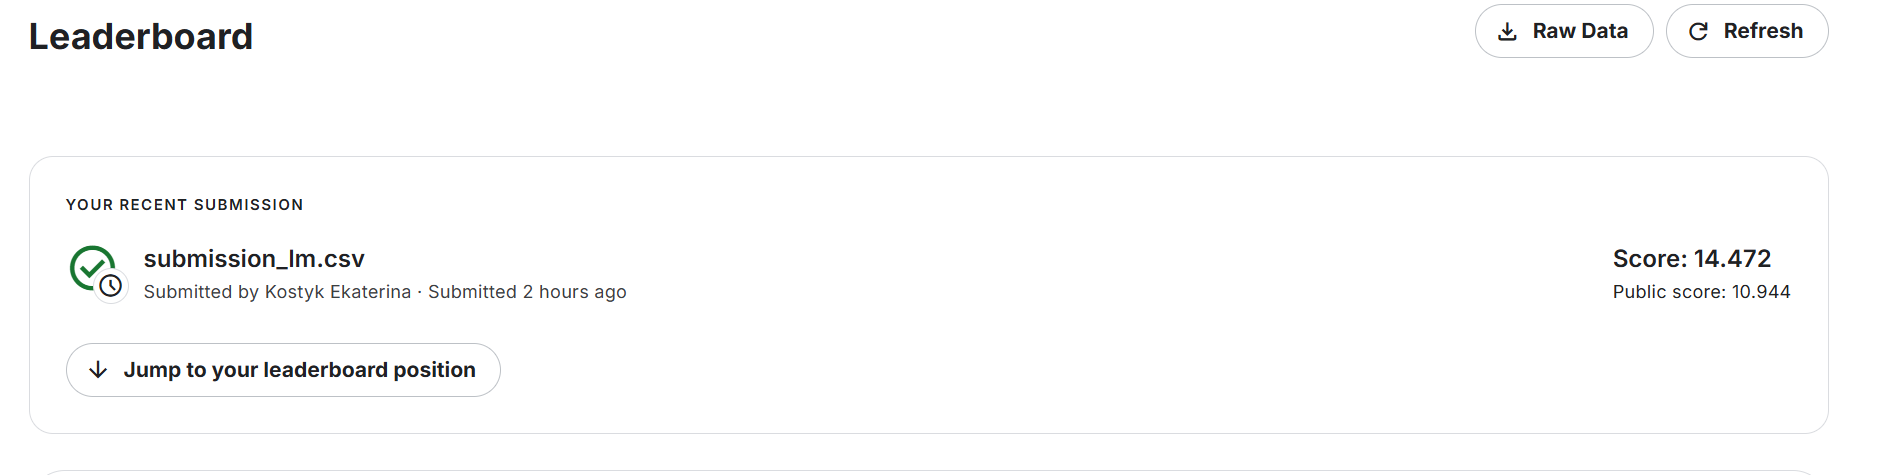